In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.metrics import calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator

In [2]:
# Load dataset
iris = load_iris()
X = iris.data

# Range of K values
K_values_elbow = range(1, 11)
K_values_ch = range(2, 11)

In [ ]:
# Elbow method

inertia = []

for k in K_values_elbow:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

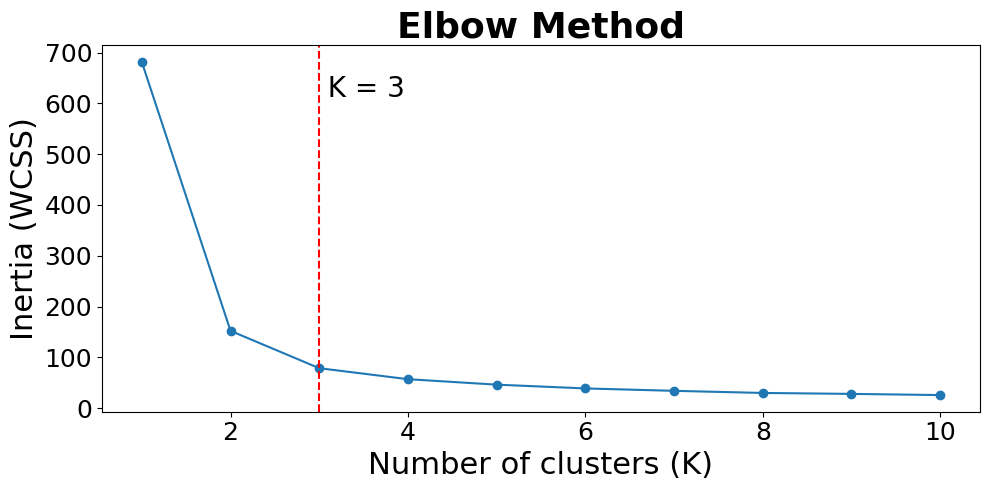

Optimal K from elbow method: 3


In [4]:
# Find elbow
knee = KneeLocator(K_values_elbow, inertia, curve="convex", direction="decreasing")
optimal_k_elbow = knee.knee

plt.figure(figsize=(10, 5))
plt.plot(K_values_elbow, inertia, marker='o')

plt.xlabel("Number of clusters (K)", fontsize=22)
plt.ylabel("Inertia (WCSS)", fontsize=22)
plt.title("Elbow Method", fontsize=26, fontweight="bold")

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

if optimal_k_elbow is not None:
    plt.axvline(x=optimal_k_elbow, linestyle='--', color="red")
    plt.text(optimal_k_elbow - 0.1, max(inertia)*0.9,
             f"  K = {optimal_k_elbow}", fontsize=20, ha='left')

plt.tight_layout()
#plt.savefig("elbow_plot.pdf", bbox_inches='tight')
plt.show()

print(f"Optimal K from elbow method: {optimal_k_elbow}")

In [ ]:
# Calinski–Harabasz index

ch_scores = []

for k in K_values_ch:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X)
    ch_scores.append(calinski_harabasz_score(X, labels))

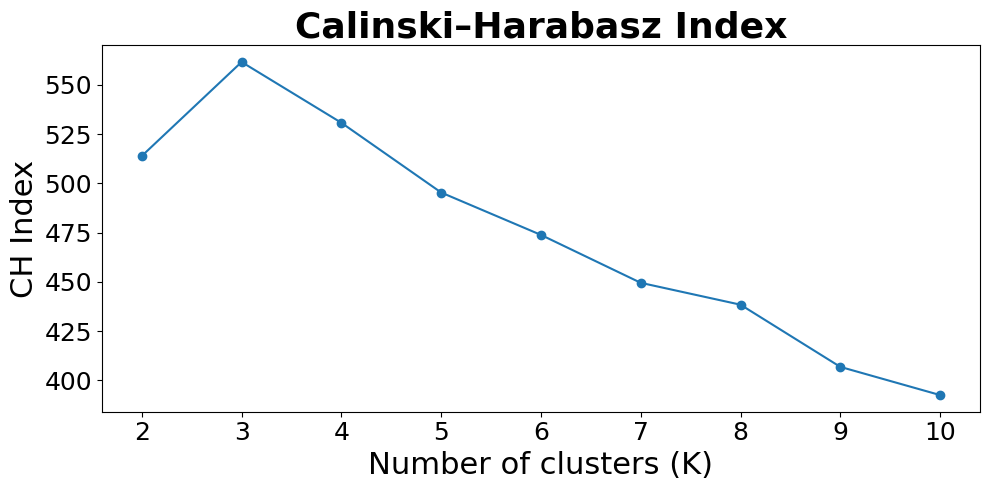

Optimal K from CH index: 3


In [6]:
optimal_k_ch = K_values_ch[np.argmax(ch_scores)]

plt.figure(figsize=(10, 5))
plt.plot(K_values_ch, ch_scores, marker='o')

plt.xlabel("Number of clusters (K)", fontsize=22)
plt.ylabel("CH Index", fontsize=22)
plt.title("Calinski–Harabasz Index", fontsize=26, fontweight="bold")

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.tight_layout()
plt.savefig("ch_plot.pdf", bbox_inches='tight')
plt.show()

print(f"Optimal K from CH index: {optimal_k_ch}")